##  Data Science is an interdisciplinary field that uses scientific methods, algorithms, and systems to extract knowledge and insights from data. It combines concepts from statistics, computer science, and domain knowledge.

# **Step 1: Create Sample Data**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#1. Customer Purchase Data (Structured)
purchase_data = pd.DataFrame({
    'customer_id': [101, 102, 103, 104, 105],
    'product_id': ['P1', 'P2', 'P3', 'P1', 'P2'],
    'amount': [1200, 800, 1500, 1100, 900],
    'date': pd.date_range(start='2025-01-01', periods=5)
})


In [ ]:
# 2. Product Reviews (Unstructured)
reviews_data = pd.DataFrame({
    'product_id': ['P1', 'P2', 'P3', 'P1', 'P2'],
    'review_text': [
        'Excellent product',
        'Not good quality',
        'Worth the price',
        'Very happy with this',
        'Average product'
    ]
})

In [ ]:
# 3. Clickstream Data (Semi-structured)
clickstream_data = pd.DataFrame({
    'session_id': [1, 2, 3, 4, 5],
    'customer_id': [101, 102, 103, 104, 105],
    'pages_visited': [5, 3, 7, 2, 6],
    'time_spent_sec': [300, 180, 400, 120, 350]
})

In [ ]:
# 4. Sensor Inventory Data (IoT)
inventory_data = pd.DataFrame({
    'product_id': ['P1', 'P2', 'P3'],
    'stock_level': [50, 20, 0]
})

# **Step 2: Data Integration (Merge All Sources)**

In [ ]:
# Display
print("Purchase Data:\n", purchase_data)
print("\nReviews:\n", reviews_data)
print("\nClickstream:\n", clickstream_data)
print("\nInventory:\n", inventory_data)


Purchase Data:
    customer_id product_id  amount       date
0          101         P1    1200 2025-01-01
1          102         P2     800 2025-01-02
2          103         P3    1500 2025-01-03
3          104         P1    1100 2025-01-04
4          105         P2     900 2025-01-05

Reviews:
   product_id           review_text
0         P1     Excellent product
1         P2      Not good quality
2         P3       Worth the price
3         P1  Very happy with this
4         P2       Average product

Clickstream:
    session_id  customer_id  pages_visited  time_spent_sec
0           1          101              5             300
1           2          102              3             180
2           3          103              7             400
3           4          104              2             120
4           5          105              6             350

Inventory:
   product_id  stock_level
0         P1           50
1         P2           20
2         P3            0


In [ ]:
# Merge purchase with reviews
data = pd.merge(purchase_data, reviews_data, on='product_id', how='left')

In [ ]:
# Merge with clickstream
data = pd.merge(data, clickstream_data, on='customer_id', how='left')

In [ ]:
# Merge with inventory
data = pd.merge(data, inventory_data, on='product_id', how='left')

In [ ]:
print("\nIntegrated Data:\n", data)

# **Step 3: Data Cleaning**

In [ ]:
# Handle missing values
data.fillna({
    'review_text': 'No Review',
    'stock_level': 0
}, inplace=True)

In [ ]:
# Remove duplicates
data.drop_duplicates(inplace=True)

In [ ]:
# Convert date
data['date'] = pd.to_datetime(data['date'])

In [ ]:
print("\nCleaned Data:\n", data)

# **Step 4: Basic Analysis**

In [ ]:
sales_summary = data.groupby('product_id')['amount'].sum()
print("\nTotal Sales:\n", sales_summary)

In [ ]:
avg_time = data['time_spent_sec'].mean()
print("\nAverage Time Spent:", avg_time)

In [ ]:
if 'stock_level' not in data.columns:
    # If 'stock_level' column is missing, re-add it by mapping from inventory_data
    stock_level_map = inventory_data.set_index('product_id')['stock_level']
    data = data.assign(stock_level=data['product_id'].map(stock_level_map).fillna(0))

low_stock = data[data['stock_level'] < 10]
print("\nLow Stock Products:\n", low_stock[['product_id', 'stock_level']])


Low Stock Products:
   product_id  stock_level
4         P3            0


In [ ]:
# Very basic sentiment classification
def sentiment(text):
    if 'excellent' in text.lower() or 'happy' in text.lower():
        return 'Positive'
    elif 'not good' in text.lower() or 'average' in text.lower():
        return 'Negative'
    else:
        return 'Neutral'

data['sentiment'] = data['review_text'].apply(sentiment)

print("\nSentiment Analysis:\n", data[['product_id', 'review_text', 'sentiment']])


Sentiment Analysis:
   product_id           review_text sentiment
0         P1     Excellent product  Positive
1         P1  Very happy with this  Positive
2         P2      Not good quality  Negative
3         P2       Average product  Negative
4         P3       Worth the price   Neutral
5         P1     Excellent product  Positive
6         P1  Very happy with this  Positive
7         P2      Not good quality  Negative
8         P2       Average product  Negative


# **Step 6: Visualization**

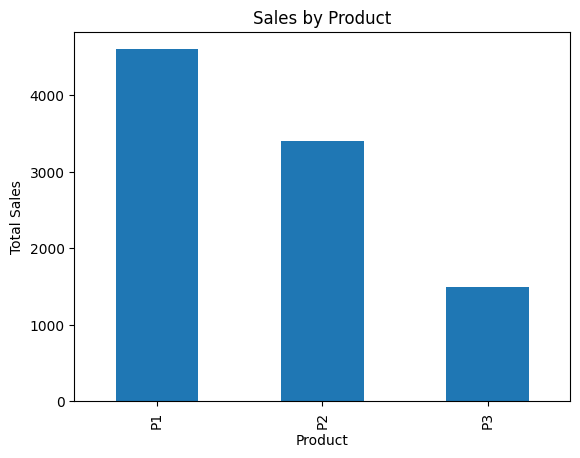

In [ ]:
import matplotlib.pyplot as plt

# Sales per product
sales_summary.plot(kind='bar')
plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.show()